In [1]:
import torch
from bevfusion.bevfusion import BEVFusion

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BEVFusion().to(device)
model.eval()
model.load_state_dict(torch.load("checkpoints/bevfusion_pytorch.pth", map_location=device))

<All keys matched successfully>

In [3]:
SAMPLE_IDX = 0 # Available index: [0, 100, 200, 300, 400]
load_path = f"data/nuscenes_demo_{SAMPLE_IDX}.pt"
demo_data = torch.load(load_path, map_location='cpu')

imgs = demo_data['imgs'].to(device)
points_mm = demo_data['points_mm'].to(device)
mats_dict_mm = {k: v.to(device) for k, v in demo_data['mats_dict_mm'].items()}

W0416 21:41:00.495000 3891236 site-packages/torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.
/home/ximeng/anaconda3/envs/bevfusion_pytorch/lib/python3.10/site-packages/spconv/pytorch/core.py:127: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  ret[slices] = updates.view(*output_shape)


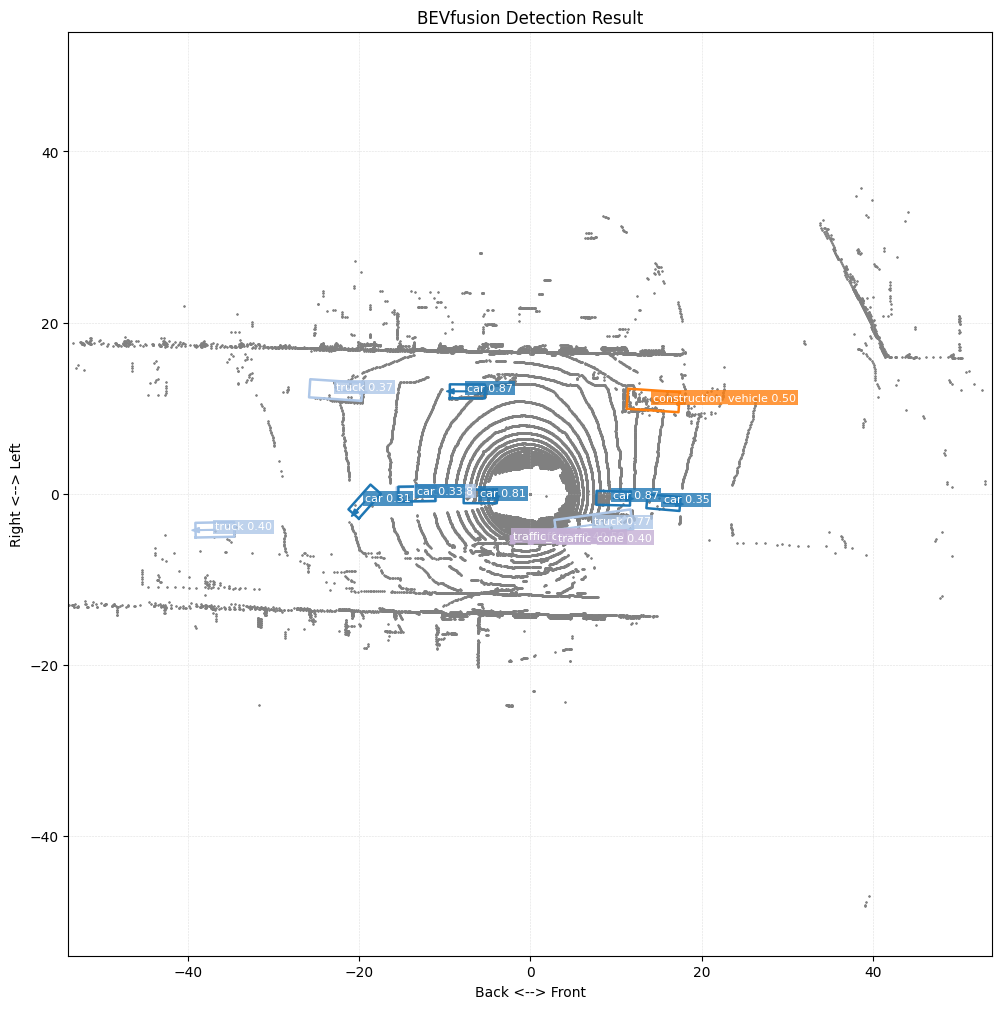

In [4]:
dict_results = model(imgs, points_mm, mats_dict_mm)
decoded_boxes_from_model = model.decode_bbox(dict_results['bbox_preds'], score_threshold=0.2)
model.visualize_results(
    points_mm[0, :, :3].cpu().numpy(),
    decoded_boxes_from_model,
    score_thr=0.3,
    point_size=0.2,
    point_alpha=0.35,
    point_color='gray'
)